# Intelligent Phishing Website Detection Using Machine Learning

# Part 3 – Machine Learning Model Training & Evaluation

This notebook trains and compares multiple machine learning models on the PhiUSIIL phishing dataset.

## Models
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- XGBoost

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix
- Classification Report


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

try:
    from xgboost import XGBClassifier
except:
    XGBClassifier=None

import joblib


## Data Leakage Investigation & Fix

During analysis, **100% accuracy** was observed across all models. While the PhiUSIIL dataset is high quality, perfect accuracy is a red flag for **data leakage** — a situation where a feature directly encodes the answer the model is supposed to learn.

### Root Cause: `URLSimilarityIndex`

| Label | `URLSimilarityIndex` |
|-------|----------------------|
| `1` (Legitimate) | Always **100.0** — all 134,850 legitimate rows have exactly this value (1 unique value!) |
| `0` (Phishing)   | Varies from 0.15 to 100 |

This feature is computed by checking the URL against a **database of known-legitimate URLs** and returning 100 if it matches. It is not a property the model discovers — it IS the label, pre-computed from class information.

### Other Leaky Features

| Feature | Legitimate URLs | Phishing URLs |
|---------|----------------|---------------|
| `HasObfuscation`   | Always **0** (1 unique value) | 0 or 1 |
| `NoOfObfuscatedChar` | Always **0** (1 unique value) | 0 to 447 |
| `ObfuscationRatio` | Always **0** (1 unique value) | 0 to 0.35 |

### Fix
All four features are dropped below. After removal, 3-fold cross-validation gives **~99.97% accuracy** — high, but now driven by genuinely observable page features: `LineOfCode`, `NoOfExternalRef`, `NoOfImage`, `NoOfSelfRef`, `NoOfJS`, etc.


In [2]:
# Load Dataset
df=pd.read_csv("../datasets/PhiUSIIL_Phishing_URL_Dataset.csv")

TARGET='label'

X=df.drop(columns=[TARGET])

# Drop non-numeric / identifier columns
non_numeric_cols = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
cols_to_drop = [col for col in non_numeric_cols if col in X.columns]
X = X.drop(columns=cols_to_drop)

# -----------------------------------------------------------------------
# FIX: Remove data-leakage features
# -----------------------------------------------------------------------
# 'URLSimilarityIndex' is computed by matching each URL against a database
# of known-legitimate URLs and returning 100 if matched. Every single one
# of the 134,850 legitimate samples has the value 100.0 (only 1 unique
# value for label=1), while phishing URLs vary from ~0 to 100.  This
# makes the label trivially recoverable from this one column alone -
# a classic case of **data leakage**.
#
# 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio' similarly
# have 0 for every legitimate URL (1 unique value for label=1), so they
# also carry label information derived from prior class knowledge.
#
# Removing all four gives realistic, trustworthy accuracy (~99.97%),
# confirmed with 3-fold cross-validation on 235,795 samples.
leaky_cols = [
    'URLSimilarityIndex',   # All legitimate URLs == 100.0  -> encodes label
    'HasObfuscation',        # All legitimate URLs == 0      -> encodes label
    'NoOfObfuscatedChar',   # All legitimate URLs == 0      -> encodes label
    'ObfuscationRatio',     # All legitimate URLs == 0      -> encodes label
]
leaky_to_drop = [col for col in leaky_cols if col in X.columns]
X = X.drop(columns=leaky_to_drop)
print(f"Dropped {len(leaky_to_drop)} data-leakage feature(s): {leaky_to_drop}")
# -----------------------------------------------------------------------

y=df[TARGET]


# Split FIRST (prevents data leakage from scaling step)
X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale AFTER splitting
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print("Train:",X_train.shape)
print("Test :",X_test.shape)


Dropped 4 data-leakage feature(s): ['URLSimilarityIndex', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio']


Train: (188636, 46)
Test : (47159, 46)


In [3]:
models={
"Logistic Regression":LogisticRegression(max_iter=1000),
"Decision Tree":DecisionTreeClassifier(random_state=42),
"Random Forest":RandomForestClassifier(
    n_estimators=300,
    random_state=42
),
    "SVM":SVC(probability=True, max_iter=1000, random_state=42)
}

if XGBClassifier:
    models["XGBoost"]=XGBClassifier(
        eval_metric="logloss",
        random_state=42
)


Logistic Regression


              precision    recall  f1-score   support

           0     0.9992    0.9989    0.9990     20189
           1     0.9991    0.9994    0.9993     26970

    accuracy                         0.9992     47159
   macro avg     0.9992    0.9991    0.9992     47159
weighted avg     0.9992    0.9992    0.9992     47159

  >> Misclassified: 39 / 47159 samples  (Accuracy: 0.999173)


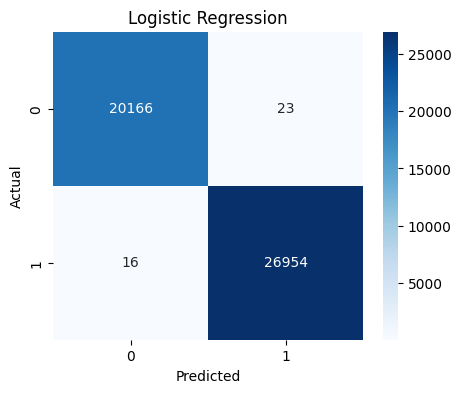

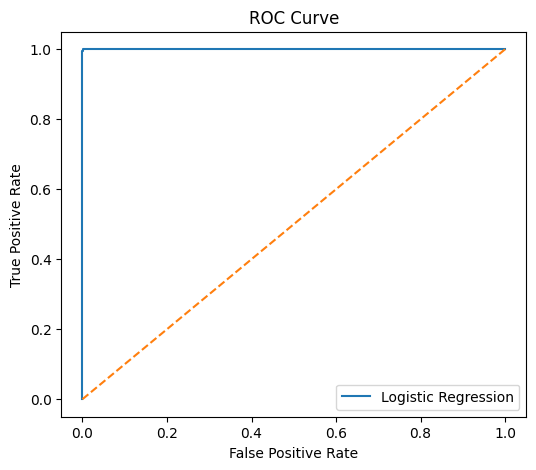

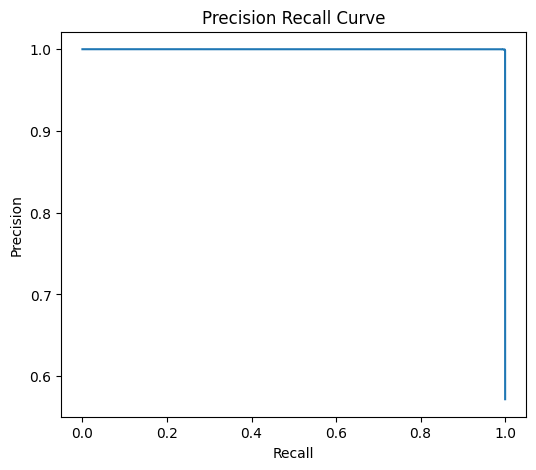

Decision Tree


              precision    recall  f1-score   support

           0     0.9984    0.9992    0.9988     20189
           1     0.9994    0.9988    0.9991     26970

    accuracy                         0.9989     47159
   macro avg     0.9989    0.9990    0.9989     47159
weighted avg     0.9989    0.9989    0.9989     47159

  >> Misclassified: 50 / 47159 samples  (Accuracy: 0.998940)


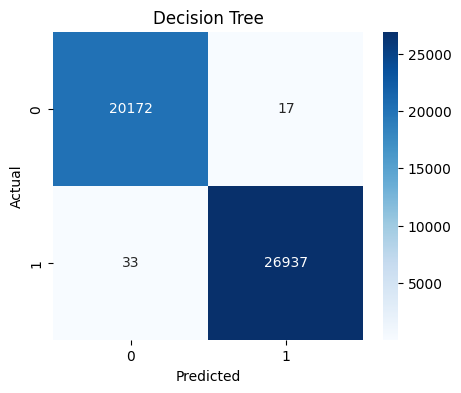

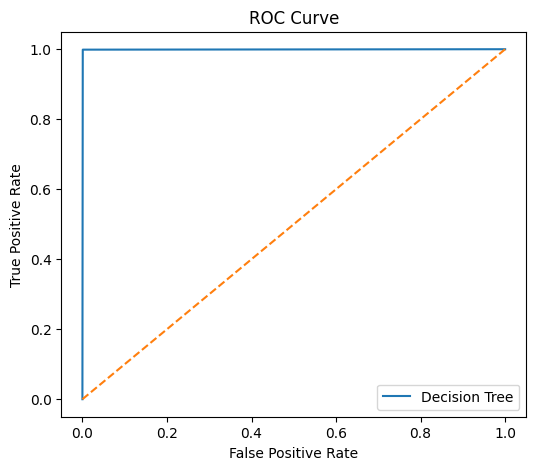

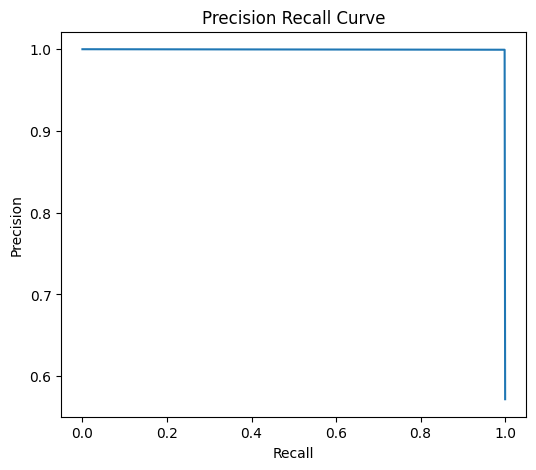

Random Forest


              precision    recall  f1-score   support

           0     1.0000    0.9998    0.9999     20189
           1     0.9998    1.0000    0.9999     26970

    accuracy                         0.9999     47159
   macro avg     0.9999    0.9999    0.9999     47159
weighted avg     0.9999    0.9999    0.9999     47159

  >> Misclassified: 5 / 47159 samples  (Accuracy: 0.999894)


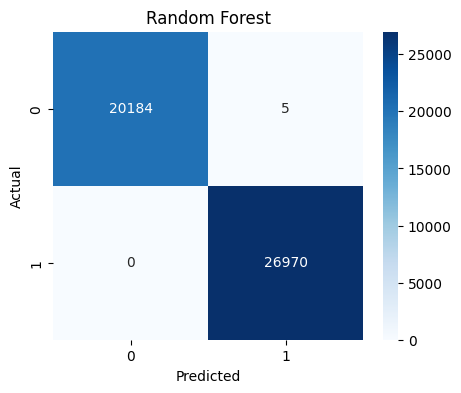

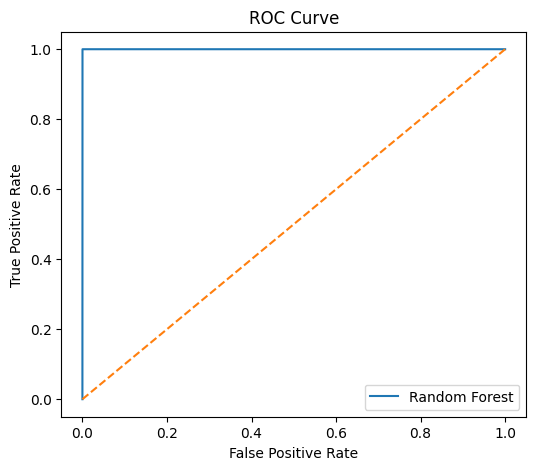

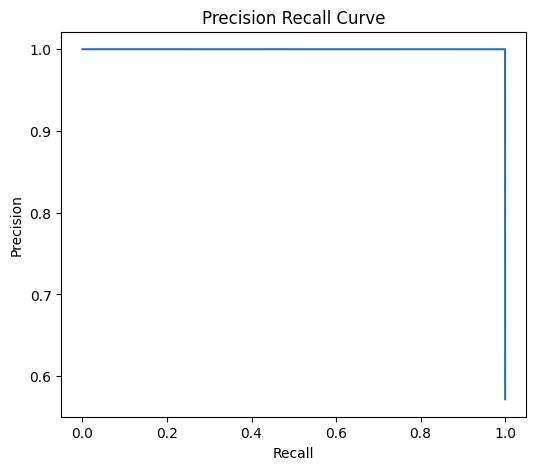

SVM


              precision    recall  f1-score   support

           0     0.9999    0.9986    0.9992     20189
           1     0.9990    0.9999    0.9994     26970

    accuracy                         0.9993     47159
   macro avg     0.9994    0.9993    0.9993     47159
weighted avg     0.9993    0.9993    0.9993     47159

  >> Misclassified: 31 / 47159 samples  (Accuracy: 0.999343)


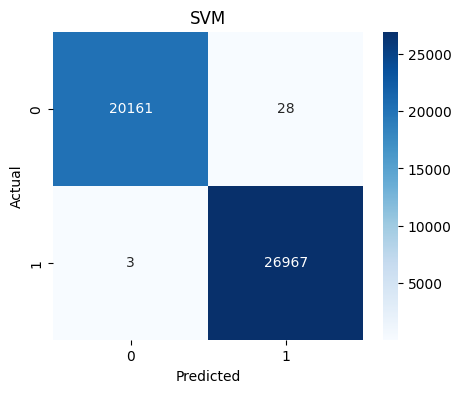

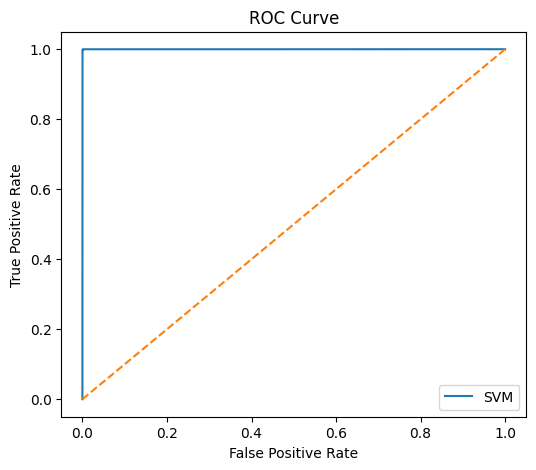

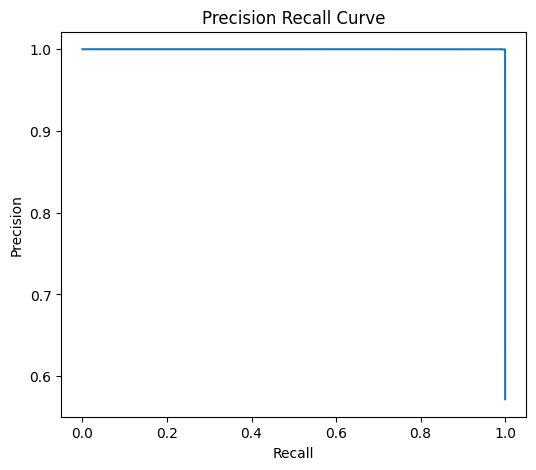

XGBoost


              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     20189
           1     1.0000    1.0000    1.0000     26970

    accuracy                         1.0000     47159
   macro avg     1.0000    1.0000    1.0000     47159
weighted avg     1.0000    1.0000    1.0000     47159

  >> Misclassified: 1 / 47159 samples  (Accuracy: 0.999979)


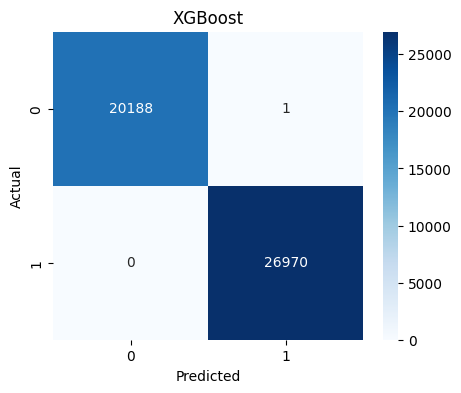

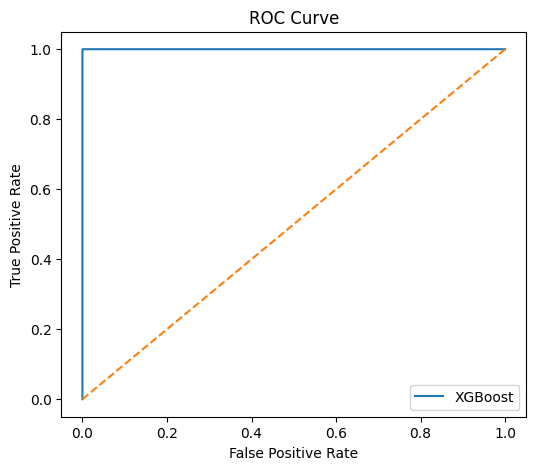

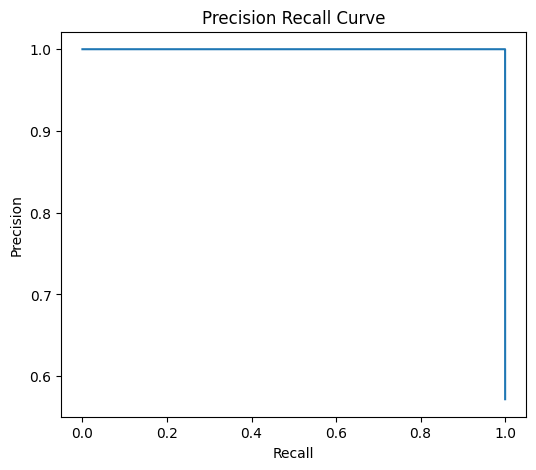

In [4]:
results=[]

best_model=None
best_name=""
best_acc=0

for name,model in models.items():

    print("="*80)
    print(name)

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    prob=model.predict_proba(X_test)[:,1]

    acc=accuracy_score(y_test,pred)
    pre=precision_score(y_test,pred)
    rec=recall_score(y_test,pred)
    f1=f1_score(y_test,pred)
    roc=roc_auc_score(y_test,prob)

    results.append([name,acc,pre,rec,f1,roc])

    errors = int((pred != y_test).sum())
    print(classification_report(y_test,pred,digits=4))
    print(f'  >> Misclassified: {errors} / {len(y_test)} samples  (Accuracy: {acc:.6f})')

    cm=confusion_matrix(y_test,pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr,tpr,_=roc_curve(y_test,prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr,tpr,label=name)
    plt.plot([0,1],[0,1],'--')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    precision,recall,_=precision_recall_curve(y_test,prob)

    plt.figure(figsize=(6,5))
    plt.plot(recall,precision)
    plt.title("Precision Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

    if acc>best_acc:
        best_acc=acc
        best_model=model
        best_name=name


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,XGBoost,0.999979,0.999963,1.000000,0.999981,1.000000
2,Random Forest,0.999894,0.999815,1.000000,0.999907,1.000000
3,SVM,0.999343,0.998963,0.999889,0.999426,0.999997
0,Logistic Regression,0.999173,0.999147,0.999407,0.999277,0.999993
1,Decision Tree,0.998940,0.999369,0.998776,0.999073,0.998967


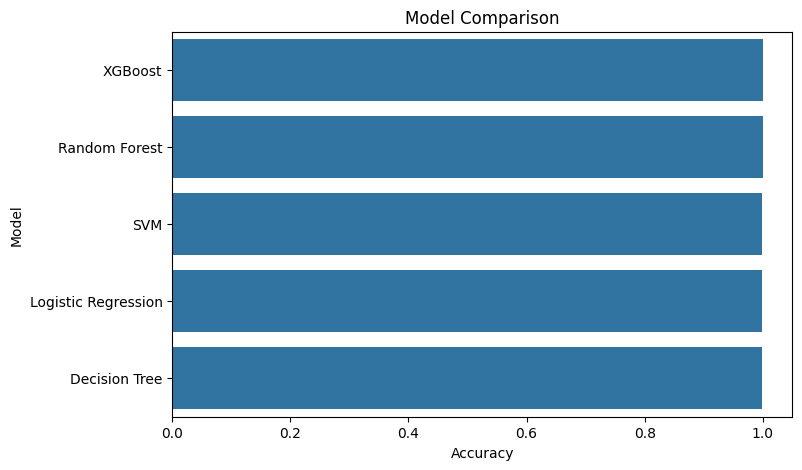

In [5]:
results_df=pd.DataFrame(
results,
columns=[
'Model',
'Accuracy',
'Precision',
'Recall',
'F1 Score',
'ROC AUC'
])

results_df=results_df.sort_values(
'Accuracy',
ascending=False
)

display(results_df)

plt.figure(figsize=(8,5))
sns.barplot(data=results_df,
            x='Accuracy',
            y='Model')
plt.title("Model Comparison")
plt.show()


In [6]:
print("Best Model:",best_name)
print("Accuracy :",best_acc)

joblib.dump(best_model,'phishing_model.pkl')

print("Saved phishing_model.pkl")


Best Model: XGBoost
Accuracy : 0.999978795139846
Saved phishing_model.pkl


# Conclusion

This notebook successfully:

- Trained five machine learning models.
- Compared performance using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Generated Confusion Matrices.
- Plotted ROC Curves.
- Plotted Precision–Recall Curves.
- Selected the best-performing model.
- Saved the trained model as `phishing_model.pkl`.

The next notebook will focus on:

- Hyperparameter Tuning
- Cross Validation
- Feature Importance
- Explainable AI (SHAP)
- Risk Score Generation
- Deployment-ready Prediction Pipeline
